In [1]:
import os

print(os.getcwd())

c:\Users\Admin\Desktop\Banking-Analytics-Project\notebooks


In [2]:
import os

print(os.getcwd())
print(os.path.exists("../data/banking_cleaned.csv"))

c:\Users\Admin\Desktop\Banking-Analytics-Project\notebooks
True


In [3]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
from warnings import filterwarnings
filterwarnings("ignore")

df = pd.read_csv("../data/banking_cleaned.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   gender                 1296675 non-null  object 
 6   city                   1296675 non-null  object 
 7   state                  1296675 non-null  object 
 8   lat                    1296675 non-null  float64
 9   long                   1296675 non-null  float64
 10  city_pop               1296675 non-null  int64  
 11  job                    1296675 non-null  object 
 12  dob                    1296675 non-null  object 
 13  merch_lat              1296675 non-null  float64
 14  merch_long        

In [5]:
print(df['trans_date_trans_time'].dtype)

object


In [6]:
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time']
)

In [7]:
df['Amount_Group'] = pd.cut(
    df['amt'],
    bins=[0,50,100,500,1000,5000,50000],
    labels=['Very Low','Low','Medium','High','Very High','Extreme']
)

In [8]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour,Amount_Group
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,...,36.011293,-82.048315,0,38,26-40,2019,January,Tuesday,0,Very Low
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,...,49.159047,-118.186462,0,48,41-60,2019,January,Tuesday,0,Medium
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,...,43.150704,-112.154481,0,64,60+,2019,January,Tuesday,0,Medium
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,...,47.034331,-112.561071,0,59,41-60,2019,January,Tuesday,0,Very Low
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,...,38.674999,-78.632459,0,40,26-40,2019,January,Tuesday,0,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,Hatch,UT,37.7175,-112.4777,...,36.841266,-111.690765,0,64,60+,2020,June,Sunday,12,Very Low
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,Tuscarora,MD,39.2667,-77.5101,...,38.906881,-78.246528,0,46,41-60,2020,June,Sunday,12,Low
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,High Rolls Mountain Park,NM,32.9396,-105.8189,...,33.619513,-105.130529,0,58,41-60,2020,June,Sunday,12,Medium
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,Manderson,SD,43.3526,-102.5411,...,42.788940,-103.241160,0,45,41-60,2020,June,Sunday,12,Low


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  object        
 6   city                   1296675 non-null  object        
 7   state                  1296675 non-null  object        
 8   lat                    1296675 non-null  float64       
 9   long                   1296675 non-null  float64       
 10  city_pop               1296675 non-null  int64         
 11  job                    1296675 non-null  object        
 12  dob                    12966

In [10]:
#  Encode Categorical Variables

# Check Unique Values
categorical_cols = [
    'category',
    'gender',
    'state',
    'job',
    'Age_Group',
    'Month',
    'Day'
]

for col in categorical_cols:
    print(col, ":", df[col].nunique())

category : 14
gender : 2
state : 51
job : 494
Age_Group : 4
Month : 12
Day : 7


In [11]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'category',
    'gender',
    'state',
    'job',
    'Age_Group',
    'Month',
    'Day'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  int64         
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  int64         
 6   city                   1296675 non-null  object        
 7   state                  1296675 non-null  int64         
 8   lat                    1296675 non-null  float64       
 9   long                   1296675 non-null  float64       
 10  city_pop               1296675 non-null  int64         
 11  job                    1296675 non-null  int64         
 12  dob                    12966

In [13]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour,Amount_Group
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",8,4.97,0,Moravian Falls,27,36.0788,-81.1781,...,36.011293,-82.048315,0,38,1,2019,4,5,0,Very Low
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",4,107.23,0,Orient,47,48.8878,-118.2105,...,49.159047,-118.186462,0,48,2,2019,4,5,0,Medium
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,0,220.11,1,Malad City,13,42.1808,-112.2620,...,43.150704,-112.154481,0,64,3,2019,4,5,0,Medium
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",2,45.00,1,Boulder,26,46.2306,-112.1138,...,47.034331,-112.561071,0,59,2,2019,4,5,0,Very Low
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,9,41.96,1,Doe Hill,45,38.4207,-79.4629,...,38.674999,-78.632459,0,40,1,2019,4,5,0,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,0,15.56,1,Hatch,44,37.7175,-112.4777,...,36.841266,-111.690765,0,64,3,2020,6,3,12,Very Low
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,1,51.70,1,Tuscarora,20,39.2667,-77.5101,...,38.906881,-78.246528,0,46,2,2020,6,3,12,Low
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,1,105.93,1,High Rolls Mountain Park,32,32.9396,-105.8189,...,33.619513,-105.130529,0,58,2,2020,6,3,12,Medium
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",1,74.90,1,Manderson,41,43.3526,-102.5411,...,42.788940,-103.241160,0,45,2,2020,6,3,12,Low


In [14]:
# encoded again
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['category'] = le.fit_transform(df['category'])
df['gender'] = le.fit_transform(df['gender'])
df['state'] = le.fit_transform(df['state'])
df['job'] = le.fit_transform(df['job'])

In [15]:
print(df[['category','gender','state','job']].dtypes)

category    int64
gender      int64
state       int64
job         int64
dtype: object


In [16]:
# Create Sample Dataset

df_sample = df.sample(
    n=200000,
    random_state=42
)

print(df_sample.shape)

(200000, 23)


In [17]:

# STEP 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import joblib

sns.set_style("whitegrid")







In [18]:
# STEP 2: FEATURES & TARGET

features = [
    'amt',
    'Age',
    'Hour',
    'city_pop',
    'category',
    'gender',
    'state',
    'job'
]

X = df_sample[features]

y = df_sample['is_fraud']

In [19]:
print(X.dtypes)

amt         float64
Age           int64
Hour          int64
city_pop      int64
category      int64
gender        int64
state         int64
job           int64
dtype: object


In [20]:

# STEP 3: TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)



In [21]:

# STEP 4: SMOTE


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")
print(y_train_smote.value_counts())

After SMOTE
is_fraud
0    159049
1    159049
Name: count, dtype: int64


In [22]:

# STEP 5: STANDARD SCALER


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

In [23]:

# STEP 6: MODEL SELECTION


lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

dt = DecisionTreeClassifier(
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)


In [24]:

# STEP 7: MODEL TRAINING


lr.fit(
    X_train_scaled,
    y_train_smote
)

dt.fit(
    X_train_smote,
    y_train_smote
)

rf.fit(
    X_train_smote,
    y_train_smote
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

print("\nAll Models Trained Successfully")






All Models Trained Successfully


In [25]:
# STEP 8: RANDOM FOREST TUNING


rf_params = {
    'n_estimators':[100],
    'max_depth':[10],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    cv=2,
    scoring='f1',
    n_iter=2,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(
    X_train_smote,
    y_train_smote
)

best_rf = rf_search.best_estimator_

print("\nBest Random Forest")
print(best_rf)





Best Random Forest
RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)


In [26]:
# STEP 9: XGBOOST TUNING


xgb_params = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.05,0.1],
    'subsample':[0.8,1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    cv=2,
    scoring='f1',
    n_iter=3,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(
    X_train_smote,
    y_train_smote
)

best_xgb = xgb_search.best_estimator_

print("\nBest XGBoost")
print(best_xgb)







Best XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [27]:
# STEP 10: MODEL COMPARISON


models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():

    if name == "Logistic Regression":

        y_pred = model.predict(
            X_test_scaled
        )

        probs = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        y_pred = model.predict(
            X_test
        )

        probs = model.predict_proba(
            X_test
        )[:,1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        probs
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

print("\nMODEL COMPARISON")
print(results_df)








MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.931075   0.064639  0.785714  0.119451  0.870481
1        Decision Tree  0.989125   0.321881  0.747899  0.450063  0.869234
2        Random Forest  0.980125   0.211399  0.857143  0.339152  0.968798
3              XGBoost  0.975125   0.178420  0.882353  0.296820  0.979584


In [28]:
# STEP 11: BEST MODEL


best_model = best_xgb

y_pred = best_model.predict(
    X_test
)

probs = best_model.predict_proba(
    X_test
)[:,1]

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     39762
           1       0.18      0.88      0.30       238

    accuracy                           0.98     40000
   macro avg       0.59      0.93      0.64     40000
weighted avg       0.99      0.98      0.98     40000



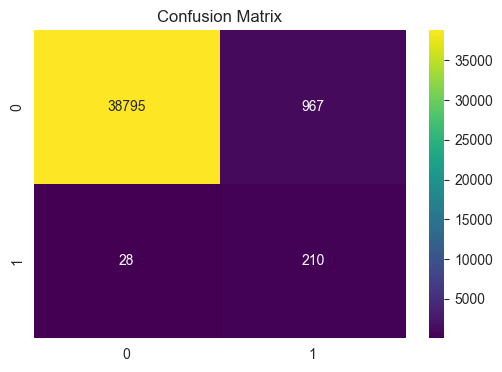

In [29]:
# STEP 12: CONFUSION MATRIX


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title("Confusion Matrix")

plt.show()

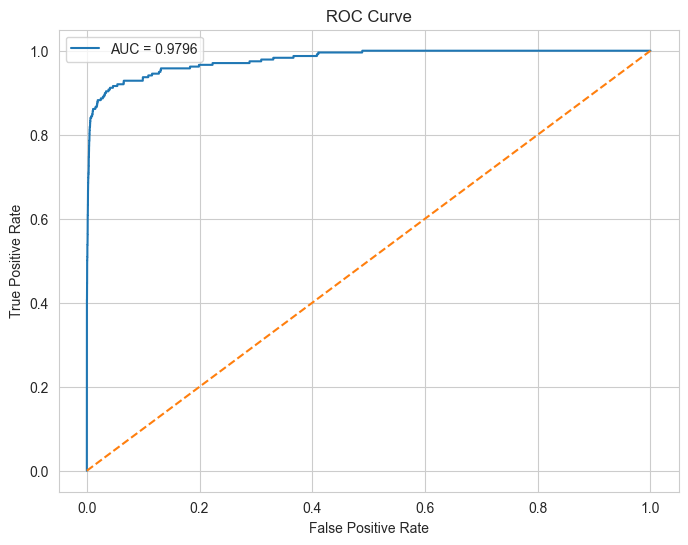

In [30]:
# STEP 13: ROC CURVE


fpr, tpr, thresholds = roc_curve(
    y_test,
    probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, probs):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

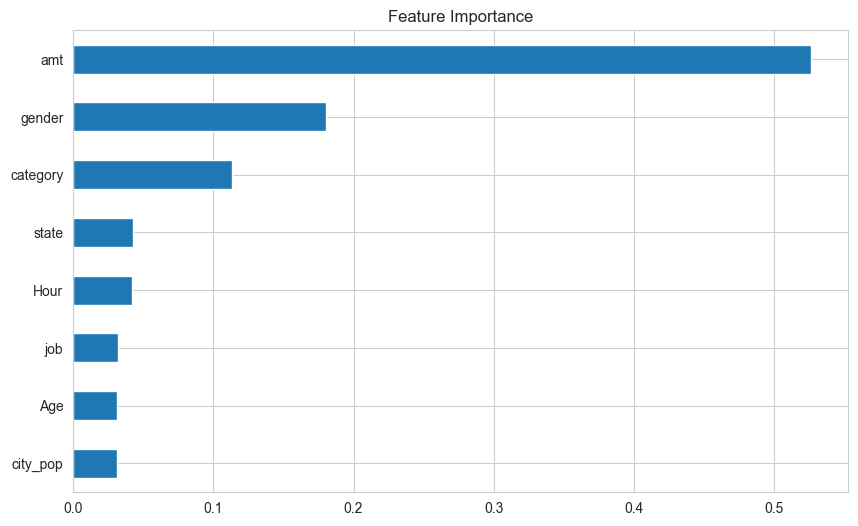

In [31]:

# FEATURE IMPORTANCE


importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()

In [32]:

# SAVE MODEL


import joblib

joblib.dump(
    best_xgb,
    "sample_dataset_fraud_model.pkl"
)

print("\nModel Saved Successfully")


Model Saved Successfully
